# Pandas

# 1 Structure DataFrame

<class 'pandas.core.frame.DataFrame'>
(891, 12)
2
10692
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
<class 'pandas.core.indexes.base.Index'>
['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    mal

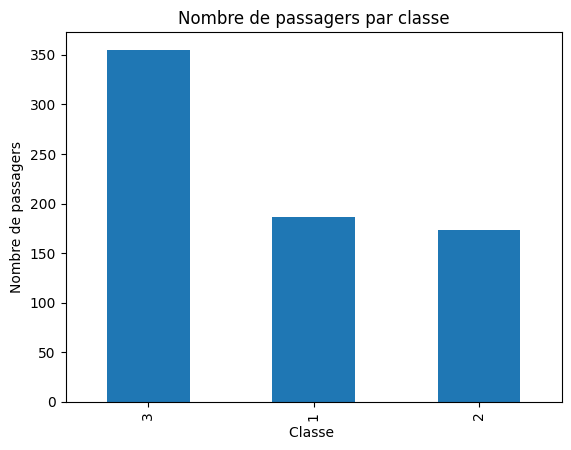

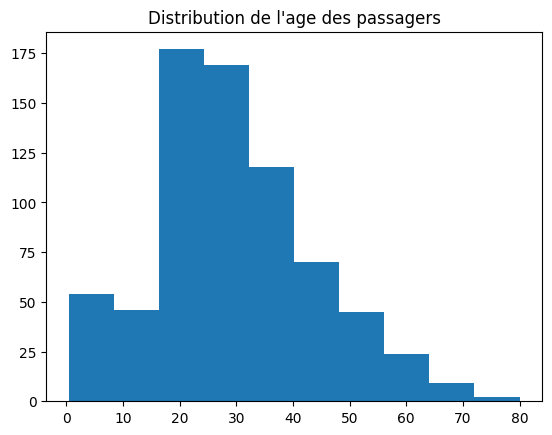

Sex
female    261
male      453
dtype: int64


In [56]:
# Importation 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd

# Lire le fichier csv
data = pd.read_csv("dataset/Titanic-Dataset.csv")
print(type(data)) # affiche le type 

df_titanic = data.copy() # faire une copie

# Déterminer les dimensions (format) de df_titanic
print(df_titanic.shape)
print(df_titanic.ndim)
print(df_titanic.size)

# Afficher les noms des colonnes de df_titanic.
print(df_titanic.columns)
print(type(df_titanic.columns))
print(df_titanic.columns.values) # Valeurs

# Lister le type des données du dataset
print(df_titanic.dtypes)

# Afficher les 5 premières et dernières lignes de df_titanic
print(df_titanic.head())
print(df_titanic.tail())

# Imprimer des informations de chaque variable du datase
print(df_titanic.info())

# Pourcentage des valeurs manquantes 
pourcentage = df_titanic["Cabin"].isna().mean() * 100
print(pourcentage)

# Suppression de la variable
df_titanic.drop(columns=["Cabin"], inplace=True)

# Déterminer les valeurs uniques de la colonne embarked et compter les
print("Valeurs uniques :")
print(df_titanic["Embarked"].unique())

print("Nombre de chaque modalité :")
print(df_titanic["Embarked"].value_counts())

# Suppresion de plusieurs colonnes
df_titanic.drop(columns=['Name', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'], inplace=True) 
df_titanic.head()

# Statistique de base 
df_titanic.describe()

# Suppression des valeurs manquantes
df_titanic.dropna(inplace=True)

# Compter le nombre de class
values = df_titanic["Pclass"].value_counts()

# Graphique sur la classe
values.plot(kind="bar")
plt.title("Nombre de passagers par classe")
plt.xlabel("Classe ")
plt.ylabel("Nombre de passagers")
plt.show()

# Graphique sur l'age
plt.hist(df_titanic["Age"])
plt.title("Distribution de l'age des passagers")
plt.show()

# Regroupement selon le sex
sex_df = df_titanic.groupby(["Sex"])
print(sex_df.size())


## 2 Structure Series

In [57]:
# Déclarer la variable serie et l’affecter à la colonne age de df_titanic.
serie = df_titanic["Age"]

print(serie)

# 2. Indexer df_titanic avec les noms des passagers. Utiliser le module set_index et la colonne name du dataframe data.
names_df = data.set_index("Name")
#print(names_df)

# Afficher le nom de chaque passager ainsi que son âge.
print(names_df["Age"])


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
886    27.0
887    19.0
889    26.0
890    32.0
Name: Age, Length: 714, dtype: float64
Name
Braund, Mr. Owen Harris                                22.0
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    38.0
Heikkinen, Miss. Laina                                 26.0
Futrelle, Mrs. Jacques Heath (Lily May Peel)           35.0
Allen, Mr. William Henry                               35.0
                                                       ... 
Montvila, Rev. Juozas                                  27.0
Graham, Miss. Margaret Edith                           19.0
Johnston, Miss. Catherine Helen "Carrie"                NaN
Behr, Mr. Karl Howell                                  26.0
Dooley, Mr. Patrick                                    32.0
Name: Age, Length: 891, dtype: float64


## 3 Indexation et slicing

In [58]:
# Afficher les 10 premières valeurs de la série age (variable age).
print(df_titanic["Age"].head(10))

# Selection des mineurs
mask = df_titanic["Age"] < 18
minor_df = df_titanic[mask]

# Regrouper tous les passagers mineurs selon leur sex et pclass.
group_minor = minor_df.groupby(["Age", "Pclass"])
print(group_minor.size())

# Selection pour label
print(df_titanic.loc[:4, ['Age', 'Sex']]) # selection des 5 premieres lignes des colonnes Age et Sex
# Selection par la position numerique 
print(df_titanic.iloc[:4, [4, 3]])

df_titanic["Modified1_age"] = df_titanic["Age"]
mask1 = df_titanic["Age"] < 18
mask2 = (df_titanic["Age"] >= 18) & (df_titanic["Age"] <= 35)
mask3 = (df_titanic["Age"] >= 35) & (df_titanic["Age"] <= 55)
mask4 = df_titanic["Age"] > 55

df_titanic.loc[mask1, "Modified1_age"] = 0
df_titanic.loc[mask2, "Modified1_age"] = 1
df_titanic.loc[mask3, "Modified1_age"] = 2
df_titanic.loc[mask4, "Modified1_age"] = 3

print(df_titanic.loc[:20,["Age", "Modified1_age"]])

# Compter le nombre de chacune des nouvelles modalités de la variable age.
print(df_titanic.groupby("Modified1_age").size())


0     22.0
1     38.0
2     26.0
3     35.0
4     35.0
6     54.0
7      2.0
8     27.0
9     14.0
10     4.0
Name: Age, dtype: float64
Age    Pclass
0.42   3          1
0.67   2          1
0.75   3          2
0.83   2          2
0.92   1          1
1.00   2          2
       3          5
2.00   1          1
       2          2
       3          7
3.00   2          3
       3          3
4.00   1          1
       2          2
       3          7
5.00   2          1
       3          3
6.00   2          1
       3          2
7.00   2          1
       3          2
8.00   2          2
       3          2
9.00   3          8
10.00  3          2
11.00  1          1
       3          3
12.00  3          1
13.00  2          1
       3          1
14.00  1          1
       2          1
       3          4
14.50  3          1
15.00  1          1
       3          4
16.00  1          3
       2          2
       3         12
17.00  1          3
       2          2
       3          8
dtype: int

## 4 Fonctions map, apply et replace

In [ ]:
# Créer une nouvelle variable modified2_age qui prend les mêmes valeurs de age.
df_titanic["Modified2_age"] = df_titanic["Age"]

# Ajout de +1 a tout le monde
df_titanic["Modified2_age"] = df_titanic["Modified2_age"].map(lambda x: x+1)

print(df_titanic)

def categories_age(x):
    if x <18:
        return 0
    elif (x >= 18) & (x <= 35):
        return 1
    elif (x >= 35) & (x <= 55):
        return 2
    else :
        return 3
    
df_titanic["Age"] = df_titanic["Age"].apply(categories_age)

# Encoder la variable sex avec la fonction replace: male ← 1 et f emale ← 2. 

df_titanic["Sex"] = df_titanic["Sex"].replace({
    'male' : 1,
    'female' : 2,
}).infer_objects(copy=False)

print(df_titanic.head())
    

     PassengerId  Survived  Pclass     Sex   Age  Modified1_age  Modified2_age
0              1         0       3    male  22.0            1.0           23.0
1              2         1       1  female  38.0            2.0           39.0
2              3         1       3  female  26.0            1.0           27.0
3              4         1       1  female  35.0            2.0           36.0
4              5         0       3    male  35.0            2.0           36.0
..           ...       ...     ...     ...   ...            ...            ...
885          886         0       3  female  39.0            2.0           40.0
886          887         0       2    male  27.0            1.0           28.0
887          888         1       1  female  19.0            1.0           20.0
889          890         1       1    male  26.0            1.0           27.0
890          891         0       3    male  32.0            1.0           33.0

[714 rows x 7 columns]
   PassengerId  Survived  Pc

C:\Users\utcpret\AppData\Local\Temp\ipykernel_13076\2563481064.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_titanic["Sex"] = df_titanic["Sex"].replace({
